In [1]:
from fastai.vision.all import *


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
labels = pd.read_csv("../input/dog-breed-identification/labels.csv")
labels


,id,breed
0,8406d837b2d7fac1c3cd621abb4c4f9e,west_highland_white_terrier
1,e270622b5ffec8294d7e7628c4ff6c1e,brittany_spaniel
2,41295c36303043fc587e791b14ef2272,basset
3,b63b0200ddbb97df81972b26574959ab,boxer
4,2c64e362c9aa29450082291264dcba29,flat-coated_retriever
...,...,...
9194,e7af8f590b4fbdca0779f5e606ef91a1,german_shepherd
9195,79deb223049ef9f441f3fcf989897d29,great_pyrenees
9196,511bfe35ff282294f6129c55bd6c33f6,malinois
9197,f7a8a885e2b28630634c3fb513277f27,lhasa


In [3]:
labels["fname"] = labels["id"].apply(lambda x: x + ".jpg")
path = "../input/dog-breed-identification/train"

dls = ImageDataLoaders.from_df(labels, path, fn_col=2,
                               item_tfms=RandomResizedCrop(460),
                               batch_tfms=[*aug_transforms(size=224), Normalize])


/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

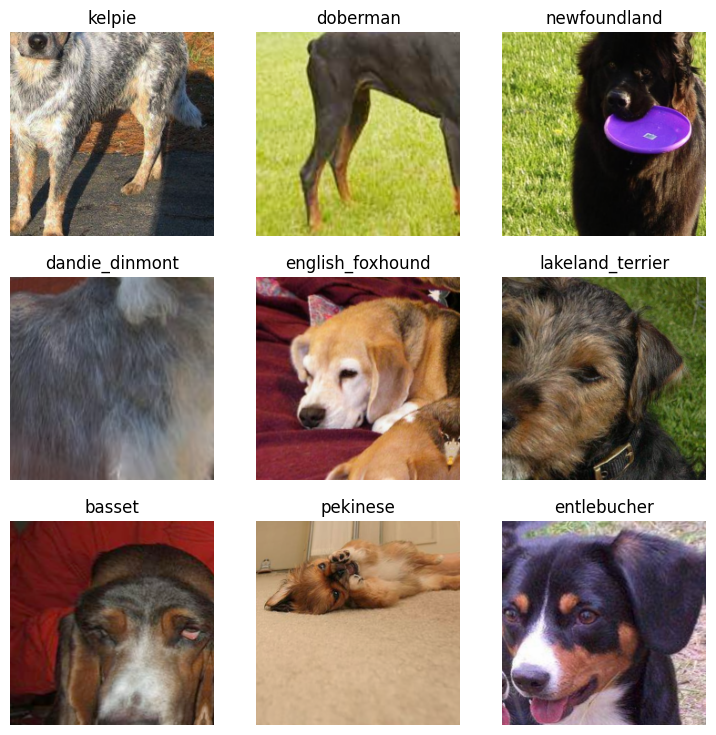

In [4]:
dls.show_batch()


In [5]:
def log_loss(inputs, targ):
    preds = torch.softmax(inputs, dim=1)
    return -1.0 * preds.gather(1, targ.view(-1, 1)).log().mean()


In [6]:
learn = cnn_learner(dls, densenet201, loss_func=log_loss, path=".").to_fp16()


/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:00<00:00, 112MB/s]


SuggestedLRs(valley=0.0005754399462603033)

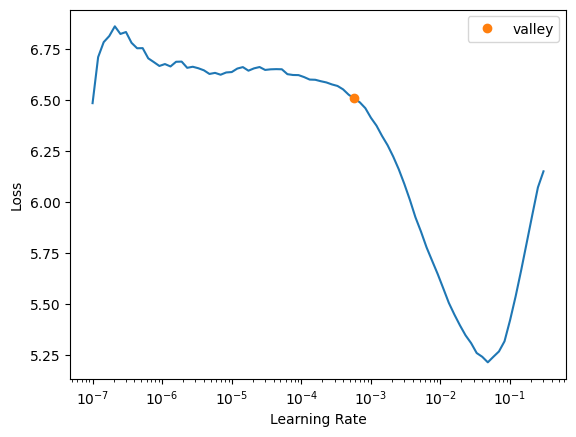

In [7]:
learn.lr_find()


In [8]:
learn.fine_tune(15, 5e-3)


epoch,train_loss,valid_loss,time
0,2.581072,0.918319,00:22


epoch,train_loss,valid_loss,time
0,1.420650,0.581390,00:27
1,1.325649,0.684229,00:27
2,1.363070,0.873730,00:27
3,1.504314,0.930633,00:27
4,1.456461,0.966344,00:27
5,1.355114,1.008875,00:27
6,1.222318,0.908433,00:27
7,1.130524,0.843788,00:27
8,0.981411,0.816871,00:27
9,0.852556,0.787461,00:27


In [9]:
test_files = get_image_files("../input/dog-breed-identification/test")
test_dl = dls.test_dl(test_files)


In [10]:
preds, targs = learn.tta(dl=test_dl)


In [11]:
preds = torch.softmax(preds, dim=1)
sub = pd.DataFrame({"id":test_files.map(lambda x:x.stem)})
sub[list(dls.vocab)] = preds
sub.to_csv("submission.csv", index=False)


/tmp/ipykernel_11/4174377554.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sub[list(dls.vocab)] = preds
/tmp/ipykernel_11/4174377554.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sub[list(dls.vocab)] = preds
/tmp/ipykernel_11/4174377554.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  

In [12]:
sub


,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,bca88d42e4fc84b3169b13a615f5fdbf,6.344422e-08,5.065736e-06,1.080379e-08,1.254027e-08,4.257308e-04,2.575412e-06,4.120339e-08,3.458304e-03,2.242252e-06,...,4.608494e-07,5.015755e-06,1.773334e-06,6.777174e-07,6.528416e-06,1.812611e-08,6.498841e-08,2.464443e-01,5.676699e-08,3.178504e-07
1,53cb3ed2547cdaf15ec7983d8325f007,2.259013e-09,2.550907e-09,6.552292e-11,1.056496e-07,2.202357e-08,2.379931e-08,5.074461e-08,5.833187e-08,2.306339e-08,...,2.965467e-08,3.377768e-08,1.443454e-05,2.477241e-07,1.741728e-06,4.914001e-09,1.402311e-09,1.254877e-09,3.072102e-09,5.764896e-09
2,726ca22c7c9c7b1043c7563a5a494cf9,2.803403e-04,6.100808e-05,1.811774e-04,4.144572e-02,5.204144e-05,6.877687e-06,5.420196e-04,1.361544e-05,1.980794e-05,...,1.131999e-04,4.680240e-05,2.169112e-05,6.248100e-05,3.265168e-04,2.685822e-05,5.535455e-04,3.478217e-06,3.593261e-04,3.457636e-04
3,48dc00c33b5f03e83f391fa306cf6c9e,1.850434e-04,2.018663e-07,1.613757e-09,2.888770e-06,6.774297e-09,5.436660e-09,2.751795e-08,1.242088e-07,5.191322e-08,...,1.260562e-05,1.383816e-08,4.078835e-09,1.644582e-09,2.120137e-08,3.807362e-10,6.828083e-08,2.827646e-08,3.898999e-05,2.539593e-07
4,7cbde2616a11273a406b99a55d18745e,1.100896e-05,2.860391e-05,3.827887e-06,3.788581e-04,2.630476e-05,5.438497e-04,8.662626e-04,2.744923e-03,1.083358e-03,...,7.937931e-06,8.608863e-04,1.570132e-03,1.881089e-02,3.951720e-05,6.509667e-06,3.268675e-06,3.272831e-05,6.102104e-05,7.230522e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,c05756fc992ab5863853dafe9cf50675,2.562916e-07,4.949467e-06,3.564984e-06,1.196297e-03,5.419920e-08,9.876433e-09,8.786072e-06,4.756150e-09,3.197506e-08,...,6.219210e-08,1.427571e-08,4.658026e-08,1.363566e-07,1.208020e-08,2.219991e-08,4.586245e-09,9.389709e-09,3.321996e-04,6.767468e-08
1019,a6d7c6cc8162c58d6f75d6f46cd6e0d4,4.314415e-08,1.486615e-08,1.864054e-07,2.631007e-09,3.718378e-01,2.594226e-06,4.452336e-09,3.247628e-05,1.151915e-05,...,3.498733e-09,2.728344e-08,8.563788e-09,3.013317e-07,3.730202e-07,1.115770e-08,6.547903e-08,2.015760e-05,3.197603e-08,1.342967e-09
1020,482e38ca587e19af6e2dfa5532da7347,6.460681e-08,2.729629e-09,3.878522e-08,1.556815e-09,7.115597e-07,7.006898e-03,2.846380e-08,6.969645e-06,1.909243e-07,...,2.465413e-09,4.640478e-08,7.499694e-09,3.760428e-07,2.217050e-08,9.557368e-10,1.080908e-08,2.360551e-08,1.446535e-09,1.826640e-09
1021,c43f8987dc2992971f4316cecc4cad73,2.548355e-05,6.558736e-07,7.927390e-06,1.903982e-06,6.479357e-07,1.913548e-08,1.911007e-03,5.391201e-07,2.429774e-06,...,4.830077e-08,6.212292e-07,2.790661e-08,1.379493e-07,3.275261e-06,6.490638e-07,9.106954e-05,1.298923e-07,6.144348e-06,4.642144e-04
